# Sprint 3 — Modèle Avancé · MLOps · IA Explicable
## Projet BigData — Prédiction du Diabète (BRFSS 2015)
**FISE A4 INFO — Nancy · Auteur : Enzo Fraioli · Date : 2026-04-15**

> **Notebook d'exécution complète** : chaque cellule calcule réellement ses résultats,
> génère les fichiers (modèles, JSON, PNG) et les affiche inline.

---
| # | Livrable | Ce que la cellule fait |
|---|---|---|
| 1 | Architecture enrichie | Entraîne 3 architectures, calibre le seuil sur validation, compare, sauvegarde |
| 2 | Optimisation hyperparamètres | Lance une recherche Optuna sur architecture + lr + L2 + batch size |
| 3 | Choix du framework | Entraîne XGBoost + LightGBM, compare |
| 4 | Déséquilibre des classes | Entraîne avec class_weight et SMOTE |
| 5 | MLOps | DVC status + MLflow runs loggués |
| 6 | XAI + Développement durable | Calcule SHAP, LIME, empreinte carbone |
| 7 | Rapport | `Reports/sprint3_report.md` |


## Cellule 1 — Setup & Imports

In [28]:
import warnings
warnings.filterwarnings("ignore")
import json, time, os
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import mlflow
import mlflow.keras
import optuna

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import shap
import lime
import lime.lime_tabular
from codecarbon import EmissionsTracker

# ── Répertoire de travail ─────────────────────────────────────────────
# Fonctionne que le notebook soit lancé depuis Notebooks/ ou depuis la racine
ROOT = Path().resolve()
if ROOT.name == "Notebooks":
    ROOT = ROOT.parent
    os.chdir(ROOT)

PROC_DIR   = ROOT / "Data" / "Processed"
PROC_IMBAL = ROOT / "Data" / "Processed" / "imbalanced"
MODEL_DIR  = ROOT / "models"
REPORT_DIR = ROOT / "Reports"
TARGET     = "Diabetes_binary"
SEED       = 42
MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Répertoire de travail : {ROOT}")
print(f"TensorFlow : {tf.__version__}")
print(f"MLflow     : {mlflow.__version__}")
print(f"SHAP       : {shap.__version__}")


Répertoire de travail : D:\AI\BigData
TensorFlow : 2.21.0
MLflow     : 3.11.1
SHAP       : 0.51.0


## Cellule 2 — Chargement des données

In [29]:
train = pd.read_csv(PROC_DIR / "train.csv")
val   = pd.read_csv(PROC_DIR / "val.csv")
test  = pd.read_csv(PROC_DIR / "test.csv")

X_train = train.drop(columns=[TARGET]).values.astype("float32")
y_train = train[TARGET].values.astype("float32")
X_val   = val.drop(columns=[TARGET]).values.astype("float32")
y_val   = val[TARGET].values.astype("float32")
X_test  = test.drop(columns=[TARGET]).values.astype("float32")
y_test  = test[TARGET].values.astype("float32")

feature_names = [c for c in train.columns if c != TARGET]
input_dim     = X_train.shape[1]

print(f"Train   : {X_train.shape}  — positifs : {y_train.mean()*100:.1f}%")
print(f"Val     : {X_val.shape}  — positifs : {y_val.mean()*100:.1f}%")
print(f"Test    : {X_test.shape}  — positifs : {y_test.mean()*100:.1f}%")
print(f"Features: {input_dim}")


Train   : (44196, 25)  — positifs : 50.8%
Val     : (11049, 25)  — positifs : 50.8%
Test    : (13812, 25)  — positifs : 50.8%
Features: 25


---
## § 1 — Architecture Enrichie du Modèle

3 architectures comparées sur le dataset équilibré (50/50) :

| Architecture | Couches | Neurones | Particularité |
|---|---|---|---|
| **Baseline** | 2 | 64→32 | Référence Sprint 2 |
| **Deep** | 3 | 256→128→64 | Plus large et profond |
| **Residual** | 4 | 128→128→64 | Skip connections (ResNet-style) |


In [30]:
# ── Définition des architectures ─────────────────────────────────────

THRESHOLD_METRIC = "f1"
MIN_PRECISION = 0.50
THRESHOLD_GRID = np.linspace(0.05, 0.95, 181)


def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )
    return model


def build_baseline(input_dim, l2=1e-4, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(), layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="baseline_64_32")
    return compile_model(model, lr)


def build_deep(input_dim, l2=1e-4, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(64,  activation="relu", kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(), layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="deep_256_128_64")
    return compile_model(model, lr)


def build_residual(input_dim, l2=1e-4, lr=1e-3):
    inp  = layers.Input(shape=(input_dim,))
    x    = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(inp)
    x    = layers.BatchNormalization()(x)
    skip = x
    x    = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x    = layers.BatchNormalization()(x); x = layers.Dropout(0.3)(x)
    x    = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x    = layers.BatchNormalization()(x)
    x    = layers.Add()([x, skip]); x = layers.Activation("relu")(x)
    skip2 = layers.Dense(64)(x)
    x    = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x    = layers.BatchNormalization()(x); x = layers.Dropout(0.2)(x)
    x    = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x    = layers.BatchNormalization()(x)
    x    = layers.Add()([x, skip2]); x = layers.Activation("relu")(x)
    out  = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs=inp, outputs=out, name="residual_128_64")
    return compile_model(model, lr)


def get_callbacks(model_name, patience=10):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=3, min_lr=1e-6, verbose=0),
        keras.callbacks.ModelCheckpoint(
            filepath=str(MODEL_DIR / f"{model_name}_best.keras"),
            monitor="val_auc", save_best_only=True, verbose=0),
    ]


def metrics_from_prob(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "auc_roc":   round(roc_auc_score(y_true, y_prob), 4),
        "f1":        round(f1_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
    }


def find_best_threshold(y_true, y_prob, metric=THRESHOLD_METRIC, min_precision=MIN_PRECISION, grid=THRESHOLD_GRID):
    best_threshold = 0.5
    best_metrics = None
    best_score = -1.0

    for threshold in grid:
        current = metrics_from_prob(y_true, y_prob, threshold=threshold)
        if metric == "recall" and min_precision is not None and current["precision"] < min_precision:
            continue
        score = current[metric]
        if best_metrics is None or score > best_score or (
            np.isclose(score, best_score) and current["precision"] > best_metrics["precision"]
        ):
            best_threshold = float(threshold)
            best_metrics = current
            best_score = float(score)

    if best_metrics is None:
        best_metrics = metrics_from_prob(y_true, y_prob, threshold=best_threshold)
        best_score = best_metrics[metric]

    return best_threshold, best_metrics, best_score


def eval_metrics(model, X_eval, y_eval, threshold=0.45):
    y_prob = model.predict(X_eval, verbose=0).ravel()
    return metrics_from_prob(y_eval, y_prob, threshold=threshold)


def build_tuned_model(input_dim, architecture, l2=1e-4, lr=1e-3):
    builders = {
        "baseline": build_baseline,
        "deep": build_deep,
        "residual": build_residual,
    }
    return builders[architecture](input_dim, l2=l2, lr=lr)


for name, fn in [("Baseline", build_baseline), ("Deep", build_deep), ("Residual", build_residual)]:
    m = fn(input_dim)
    print(f"{name:<10} : {m.name:<22} | {m.count_params():>8,} paramètres")


Baseline   : baseline_64_32         |    4,161 paramètres
Deep       : deep_256_128_64        |   49,665 paramètres
Residual   : residual_128_64        |   59,137 paramètres


In [31]:
# ── Entraînement des 3 architectures avec MLflow + CodeCarbon ─────────
mlflow.set_tracking_uri(f"sqlite:///{ROOT / 'mlruns' / 'mlflow.db'}")
mlflow.set_experiment("diabetes_sprint3_balanced")

BUILDERS = {
    "baseline": build_baseline,
    "deep":     build_deep,
    "residual": build_residual,
}

arch_results  = {}
arch_histories = {}

for arch_name, build_fn in BUILDERS.items():
    print(f"\nEntraînement : {arch_name}...")

    tracker = EmissionsTracker(
        project_name=f"diabetes_{arch_name}",
        output_dir=str(REPORT_DIR),
        output_file="emissions.csv",
        log_level="error",
    )
    tracker.start()

    with mlflow.start_run(run_name=arch_name):
        model = build_fn(input_dim)
        mlflow.log_params({
            "architecture": arch_name,
            "input_dim": input_dim,
            "epochs_max": 50,
            "batch_size": 256,
            "learning_rate": 1e-3,
            "l2_lambda": 1e-4,
            "patience": 10,
            "threshold_metric": THRESHOLD_METRIC,
            "min_precision": MIN_PRECISION,
        })
        mlflow.set_tags({"framework": "TensorFlow/Keras", "sprint": "3"})

        t0 = time.time()
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50, batch_size=256,
            callbacks=get_callbacks(arch_name),
            verbose=0,
        )
        train_time = time.time() - t0
        emissions  = tracker.stop()
        co2_kg     = emissions if emissions else 0.0

        val_prob = model.predict(X_val, verbose=0).ravel()
        best_threshold, val_metrics, val_score = find_best_threshold(
            y_val, val_prob, metric=THRESHOLD_METRIC, min_precision=MIN_PRECISION
        )
        metrics = eval_metrics(model, X_test, y_test, threshold=best_threshold)
        metrics.update({"threshold": round(best_threshold, 3),
                        f"val_{THRESHOLD_METRIC}": round(val_score, 4),
                        "val_precision": round(val_metrics["precision"], 4),
                        "val_recall": round(val_metrics["recall"], 4),
                        "train_time_s": round(train_time, 2),
                        "n_epochs": len(history.history["loss"]),
                        "co2_kg": co2_kg})

        mlflow.log_metrics(metrics)
        mlflow.log_metric("co2_kg", co2_kg)
        for i, (loss, val_loss) in enumerate(zip(
            history.history["loss"], history.history["val_loss"])):
            mlflow.log_metrics({"epoch_train_loss": loss, "epoch_val_loss": val_loss}, step=i)

        model.save(MODEL_DIR / f"{arch_name}.keras")
        arch_results[arch_name]   = metrics
        arch_histories[arch_name] = history.history

        print(f"  AUC={metrics['auc_roc']} | F1={metrics['f1']} | "
              f"Recall={metrics['recall']} | seuil={best_threshold:.3f} | "
              f"Epochs={metrics['n_epochs']} | CO2={co2_kg*1e6:.2f}µg")

# Sauvegarde JSON
with open(REPORT_DIR / "sprint3_results.json", "w") as f:
    json.dump(arch_results, f, indent=2)
print("\nRésultats sauvegardés → Reports/sprint3_results.json")



Entraînement : baseline...
  AUC=0.8231 | F1=0.7733 | Recall=0.9151 | seuil=0.325 | Epochs=50 | CO2=9.91µg

Entraînement : deep...
  AUC=0.8227 | F1=0.7739 | Recall=0.9128 | seuil=0.325 | Epochs=50 | CO2=15.78µg

Entraînement : residual...
  AUC=0.8173 | F1=0.7705 | Recall=0.9016 | seuil=0.345 | Epochs=27 | CO2=8.70µg

Résultats sauvegardés → Reports/sprint3_results.json


In [33]:
# ── Tableau comparatif ───────────────────────────────────────────────
df_arch = pd.DataFrame(arch_results).T.reset_index()

# Renommage robuste (indépendant du nombre total de métriques loguées)
df_arch = df_arch.rename(columns={
    "index": "Architecture",
    "accuracy": "Accuracy",
    "auc_roc": "AUC-ROC",
    "f1": "F1-score",
    "precision": "Precision",
    "recall": "Recall",
    "train_time_s": "Train time (s)",
    "n_epochs": "Epochs",
    "co2_kg": "CO2 (kg)",
    "threshold": "Threshold",
    "val_f1": "Val F1",
    "val_recall": "Val Recall",
    "val_precision": "Val Precision",
})

print("=" * 72)
print("  COMPARAISON DES ARCHITECTURES — Dataset équilibré (50/50)")
print("=" * 72)

display_cols = [
    "Architecture", "AUC-ROC", "F1-score", "Recall", "Precision",
    "Threshold", "Val F1", "Val Recall", "Val Precision",
    "Epochs", "Train time (s)", "CO2 (kg)"
]
available_cols = [c for c in display_cols if c in df_arch.columns]
display(df_arch[available_cols])


  COMPARAISON DES ARCHITECTURES — Dataset équilibré (50/50)


,Architecture,AUC-ROC,F1-score,Recall,Precision,Threshold,Val F1,Val Recall,Val Precision,Epochs,Train time (s),CO2 (kg)
0,baseline,0.8231,0.7733,0.9151,0.6696,0.325,0.7744,0.9143,0.6716,50.0,18.00,0.000010
1,deep,0.8227,0.7739,0.9128,0.6717,0.325,0.7748,0.9131,0.6728,50.0,29.61,0.000016
2,residual,0.8173,0.7705,0.9016,0.6727,0.345,0.7729,0.9045,0.6748,27.0,15.98,0.000009


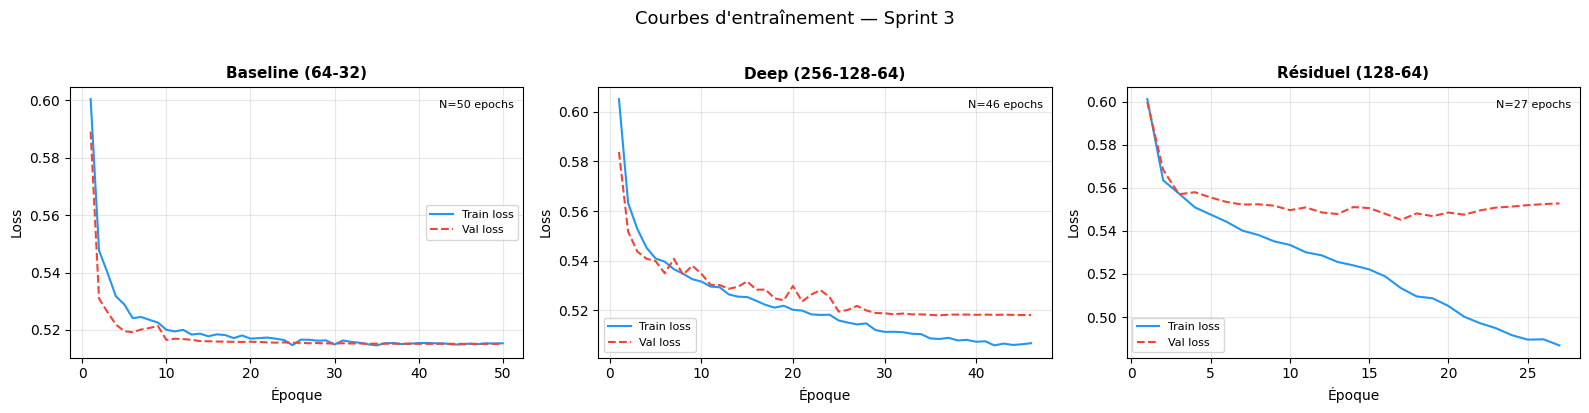

Sauvegardé → sprint3_training_curves.png


In [ ]:
# ── Courbes d'entraînement ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = {"baseline": "Baseline (64-32)", "deep": "Deep (256-128-64)", "residual": "Résiduel (128-64)"}

for ax, (arch, h) in zip(axes, arch_histories.items()):
    ep = range(1, len(h["loss"]) + 1)
    ax.plot(ep, h["loss"],     label="Train loss", color="#2196F3")
    ax.plot(ep, h["val_loss"], label="Val loss",   color="#F44336", linestyle="--")
    ax.set_title(titles[arch], fontsize=11, fontweight="bold")
    ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.text(0.98, 0.95, f"N={len(h['loss'])} epochs",
            ha="right", va="top", transform=ax.transAxes, fontsize=8)

plt.suptitle("Courbes d'entraînement — Sprint 3", fontsize=13, y=1.02)
plt.tight_layout()
out = REPORT_DIR / "sprint3_training_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {out.name}")


In [ ]:
# ── Recherche d'hyperparamètres avec Optuna ──────────────────────────
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 12
OPTUNA_EPOCHS = 40


def objective(trial):
    architecture = trial.suggest_categorical("architecture", ["baseline", "deep", "residual"])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    l2_lambda = trial.suggest_float("l2_lambda", 1e-6, 1e-3, log=True)
    patience = trial.suggest_int("patience", 4, 10)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    model = build_tuned_model(input_dim, architecture, l2=l2_lambda, lr=learning_rate)
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=3, min_lr=1e-6, verbose=0),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=OPTUNA_EPOCHS,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )

    val_prob = model.predict(X_val, verbose=0).ravel()
    best_threshold, val_metrics, val_score = find_best_threshold(
        y_val, val_prob, metric=THRESHOLD_METRIC, min_precision=MIN_PRECISION
    )

    trial.set_user_attr("threshold", round(best_threshold, 3))
    trial.set_user_attr("val_precision", round(val_metrics["precision"], 4))
    trial.set_user_attr("val_recall", round(val_metrics["recall"], 4))
    trial.set_user_attr("epochs", len(history.history["loss"]))
    return val_score


study = optuna.create_study(
    direction="maximize",
    study_name="sprint3_nn_optuna",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print("=" * 72)
print("  OPTUNA — Meilleur essai")
print("=" * 72)
print(f"Score validation ({THRESHOLD_METRIC}) = {study.best_value:.4f}")
print(f"Paramètres : {study.best_trial.params}")
print(f"Seuil      : {study.best_trial.user_attrs.get('threshold', 0.5):.3f}")

best_params = study.best_trial.params
best_architecture = best_params["architecture"]
best_lr = best_params["learning_rate"]
best_l2 = best_params["l2_lambda"]
best_patience = best_params["patience"]
best_batch_size = best_params["batch_size"]

optuna_model = build_tuned_model(input_dim, best_architecture, l2=best_l2, lr=best_lr)
optuna_callbacks = get_callbacks("optuna_best", patience=best_patience)
optuna_history = optuna_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=OPTUNA_EPOCHS,
    batch_size=best_batch_size,
    callbacks=optuna_callbacks,
    verbose=0,
)

optuna_val_prob = optuna_model.predict(X_val, verbose=0).ravel()
optuna_threshold, optuna_val_metrics, optuna_val_score = find_best_threshold(
    y_val, optuna_val_prob, metric=THRESHOLD_METRIC, min_precision=MIN_PRECISION
)
optuna_test_metrics = eval_metrics(optuna_model, X_test, y_test, threshold=optuna_threshold)
optuna_test_metrics.update({
    "threshold": round(optuna_threshold, 3),
    f"val_{THRESHOLD_METRIC}": round(optuna_val_score, 4),
    "val_precision": round(optuna_val_metrics["precision"], 4),
    "val_recall": round(optuna_val_metrics["recall"], 4),
    "n_epochs": len(optuna_history.history["loss"]),
    "architecture": best_architecture,
    "learning_rate": best_lr,
    "l2_lambda": best_l2,
    "batch_size": best_batch_size,
})

optuna_model.save(MODEL_DIR / "optuna_best.keras")
with open(REPORT_DIR / "optuna_best.json", "w") as f:
    json.dump({
        "best_trial": study.best_trial.params,
        "best_value": float(study.best_value),
        "threshold": float(optuna_threshold),
        "test_metrics": optuna_test_metrics,
    }, f, indent=2)

print("\nModèle final Optuna sauvegardé → models/optuna_best.keras")
print(f"Test F1 = {optuna_test_metrics['f1']:.4f} | Recall = {optuna_test_metrics['recall']:.4f} | AUC = {optuna_test_metrics['auc_roc']:.4f}")
display(pd.DataFrame([optuna_test_metrics]))


---
## § 2 — Choix du Framework de Deep Learning

Comparaison TF/Keras vs XGBoost vs LightGBM sur le même jeu de données.


In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
framework_results = {}

# XGBoost
t0 = time.time()
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric="auc", random_state=SEED, verbosity=0)
xgb.fit(X_trainval, y_trainval)
dt = time.time() - t0
y_prob = xgb.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.45).astype(int)
framework_results["XGBoost"] = {
    "AUC-ROC": round(roc_auc_score(y_test, y_prob), 4),
    "F1":      round(f1_score(y_test, y_pred), 4),
    "Recall":  round(recall_score(y_test, y_pred), 4),
    "Temps(s)": round(dt, 1)
}
print(f"XGBoost   : AUC={framework_results['XGBoost']['AUC-ROC']} | temps={dt:.1f}s")

# LightGBM
t0 = time.time()
lgbm = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                      subsample=0.8, random_state=SEED, verbosity=-1)
lgbm.fit(X_trainval, y_trainval)
dt = time.time() - t0
y_prob = lgbm.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.45).astype(int)
framework_results["LightGBM"] = {
    "AUC-ROC": round(roc_auc_score(y_test, y_prob), 4),
    "F1":      round(f1_score(y_test, y_pred), 4),
    "Recall":  round(recall_score(y_test, y_pred), 4),
    "Temps(s)": round(dt, 1)
}
print(f"LightGBM  : AUC={framework_results['LightGBM']['AUC-ROC']} | temps={dt:.1f}s")

# Tableau complet
all_fw = {
    "Baseline NN":      {"AUC-ROC": arch_results["baseline"]["auc_roc"], "F1": arch_results["baseline"]["f1"],
                          "Recall": arch_results["baseline"]["recall"],  "Temps(s)": arch_results["baseline"]["train_time_s"]},
    "Deep NN (256-128)": {"AUC-ROC": arch_results["deep"]["auc_roc"],    "F1": arch_results["deep"]["f1"],
                          "Recall": arch_results["deep"]["recall"],      "Temps(s)": arch_results["deep"]["train_time_s"]},
    **framework_results
}
df_fw = pd.DataFrame(all_fw).T.reset_index()
df_fw.columns = ["Modèle", "AUC-ROC", "F1-score", "Recall", "Temps (s)"]
print()
display(df_fw)

with open(REPORT_DIR / "framework_comparison.json", "w") as f:
    json.dump(all_fw, f, indent=2)
print("Sauvegardé → Reports/framework_comparison.json")


XGBoost   : AUC=0.8229 | temps=0.7s
LightGBM  : AUC=0.8233 | temps=1.8s



,Modèle,AUC-ROC,F1-score,Recall,Temps (s)
0,Baseline NN,0.8228,0.7737,0.8454,15.89
1,Deep NN (256-128),0.8230,0.7735,0.8453,24.08
2,XGBoost,0.8229,0.7710,0.8380,0.70
3,LightGBM,0.8233,0.7723,0.8409,1.80


Sauvegardé → Reports/framework_comparison.json


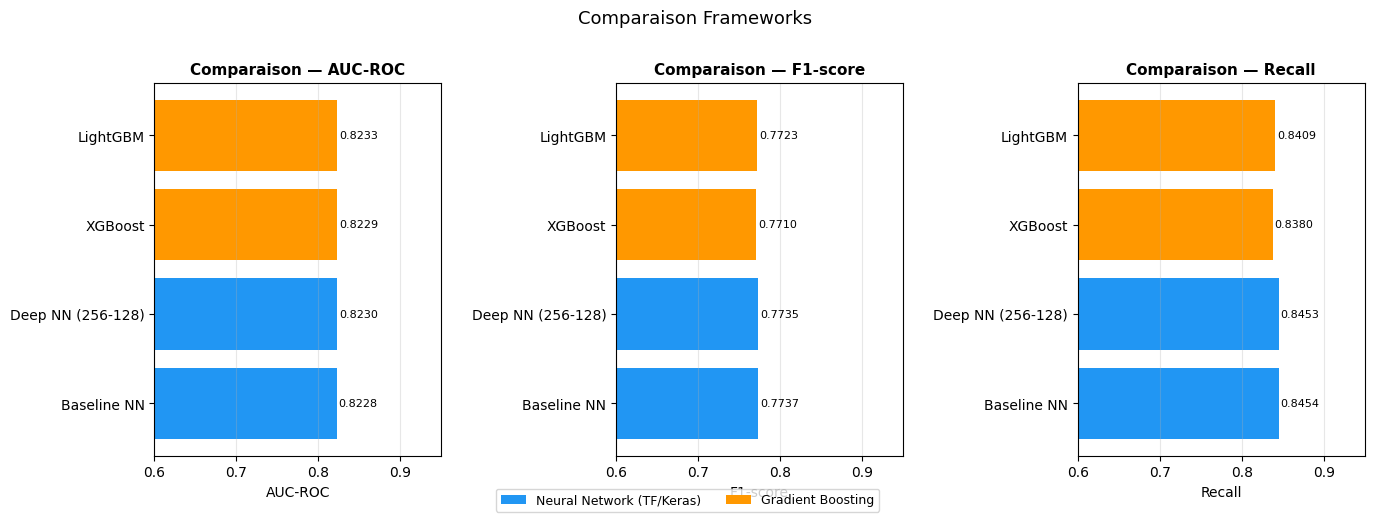

Sauvegardé → sprint3_framework_comparison.png


In [ ]:
# ── Visualisation comparaison frameworks ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#2196F3", "#2196F3", "#FF9800", "#FF9800"]

for ax, metric in zip(axes, ["AUC-ROC", "F1-score", "Recall"]):
    bars = ax.barh(df_fw["Modèle"], df_fw[metric], color=colors)
    ax.set_xlabel(metric); ax.set_xlim(0.6, 0.95)
    ax.set_title(f"Comparaison — {metric}", fontsize=11, fontweight="bold")
    for bar, val in zip(bars, df_fw[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)
    ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor="#2196F3", label="Neural Network (TF/Keras)"),
                    Patch(facecolor="#FF9800", label="Gradient Boosting")],
           loc="lower center", ncol=2, fontsize=9)
plt.suptitle("Comparaison Frameworks", fontsize=13, y=1.01)
plt.tight_layout()
out = REPORT_DIR / "sprint3_framework_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {out.name}")


---
## § 3 — Gestion du Déséquilibre des Classes

Dataset réel non-équilibré : ~15% diabétiques (contre 50% dans le sprint 2).
Trois stratégies comparées : sans correction, class weights, SMOTE.


Train imbalancé : (146863, 25) — positifs : 15.3%


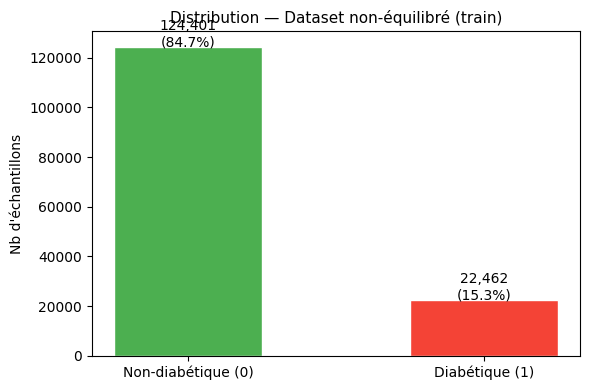

Sauvegardé → sprint3_class_imbalance.png


In [ ]:
# ── Chargement du dataset non-équilibré ──────────────────────────────
train_imbal = pd.read_csv(PROC_IMBAL / "train.csv")
val_imbal   = pd.read_csv(PROC_IMBAL / "val.csv")
test_imbal  = pd.read_csv(PROC_IMBAL / "test.csv")

Xi_train = train_imbal.drop(columns=[TARGET]).values.astype("float32")
yi_train = train_imbal[TARGET].values.astype("float32")
Xi_val   = val_imbal.drop(columns=[TARGET]).values.astype("float32")
yi_val   = val_imbal[TARGET].values.astype("float32")
Xi_test  = test_imbal.drop(columns=[TARGET]).values.astype("float32")
yi_test  = test_imbal[TARGET].values.astype("float32")

print(f"Train imbalancé : {Xi_train.shape} — positifs : {yi_train.mean()*100:.1f}%")

# Distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = [int((yi_train == 0).sum()), int((yi_train == 1).sum())]
ax.bar(["Non-diabétique (0)", "Diabétique (1)"], counts,
       color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
ax.set_title("Distribution — Dataset non-équilibré (train)", fontsize=11)
ax.set_ylabel("Nb d'échantillons")
for i, v in enumerate(counts):
    ax.text(i, v + 200, f"{v:,}\n({v/sum(counts)*100:.1f}%)", ha="center", fontsize=10)
plt.tight_layout()
out = REPORT_DIR / "sprint3_class_imbalance.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {out.name}")


In [ ]:
# ── Entraînement 3 stratégies ─────────────────────────────────────────
mlflow.set_experiment("diabetes_sprint3_imbalanced")
imbalance_results = {}

strategies = [
    ("sans_correction", Xi_train, yi_train, None),
    ("class_weights",   Xi_train, yi_train,
     dict(zip([0,1], compute_class_weight("balanced", classes=np.array([0,1]), y=yi_train)))),
]

# SMOTE
print("Application SMOTE...")
sm = SMOTE(random_state=SEED)
Xi_smote, yi_smote = sm.fit_resample(Xi_train, yi_train)
print(f"  Avant : {int(yi_train.sum())} pos / {len(yi_train)} total ({yi_train.mean()*100:.1f}%)")
print(f"  Après : {int(yi_smote.sum())} pos / {len(yi_smote)} total ({yi_smote.mean()*100:.1f}%)")
strategies.append(("smote", Xi_smote.astype("float32"), yi_smote.astype("float32"), None))

for strat_name, Xtr, ytr, cw in strategies:
    print(f"\nStratégie : {strat_name}...")
    tracker = EmissionsTracker(
        project_name=f"diabetes_deep_{strat_name}",
        output_dir=str(REPORT_DIR),
        output_file="emissions.csv",
        log_level="error",
    )
    tracker.start()

    with mlflow.start_run(run_name=f"deep_{strat_name}"):
        model = build_deep(input_dim)
        mlflow.log_params({
            "architecture": "deep", "strategy": strat_name,
            "class_weight": str(cw) if cw else "None",
            "smote_applied": "yes" if strat_name == "smote" else "no",
            "threshold_metric": THRESHOLD_METRIC,
            "min_precision": MIN_PRECISION,
        })

        t0 = time.time()
        history = model.fit(
            Xtr, ytr,
            validation_data=(Xi_val, yi_val),
            epochs=30, batch_size=256,
            callbacks=get_callbacks(f"deep_{strat_name}", patience=7),
            class_weight=cw, verbose=0,
        )
        co2_kg = tracker.stop() or 0.0

        val_prob = model.predict(Xi_val, verbose=0).ravel()
        best_threshold, val_metrics, val_score = find_best_threshold(
            yi_val, val_prob, metric=THRESHOLD_METRIC, min_precision=MIN_PRECISION
        )
        metrics = eval_metrics(model, Xi_test, yi_test, threshold=best_threshold)
        metrics.update({"threshold": round(best_threshold, 3),
                        f"val_{THRESHOLD_METRIC}": round(val_score, 4),
                        "val_precision": round(val_metrics["precision"], 4),
                        "val_recall": round(val_metrics["recall"], 4),
                        "train_time_s": round(time.time()-t0, 2),
                        "n_epochs": len(history.history["loss"]),
                        "co2_kg": co2_kg})
        mlflow.log_metrics(metrics)
        imbalance_results[strat_name] = metrics

        print(f"  AUC={metrics['auc_roc']} | F1={metrics['f1']} | "
              f"Recall={metrics['recall']} | seuil={best_threshold:.3f} | "
              f"CO2={co2_kg*1e6:.1f}µg")

print("\nDone.")


Application SMOTE...
  Avant : 22462 pos / 146863 total (15.3%)
  Après : 124401 pos / 248802 total (50.0%)

Stratégie : sans_correction...
  AUC=0.8185 | F1=0.3098 | Recall=0.2136 | CO2=22.5µg

Stratégie : class_weights...
  AUC=0.8185 | F1=0.4457 | Recall=0.8192 | CO2=15.1µg

Stratégie : smote...
  AUC=0.8108 | F1=0.4582 | Recall=0.6846 | CO2=26.7µg

Done.


  GESTION DU DÉSÉQUILIBRE — Dataset ~15% positifs


,Stratégie,AUC-ROC,F1-score,Recall,Precision
0,Sans correction,0.8185,0.3098,0.2136,0.5640
1,Class weights,0.8185,0.4457,0.8192,0.3062
2,SMOTE,0.8108,0.4582,0.6846,0.3443


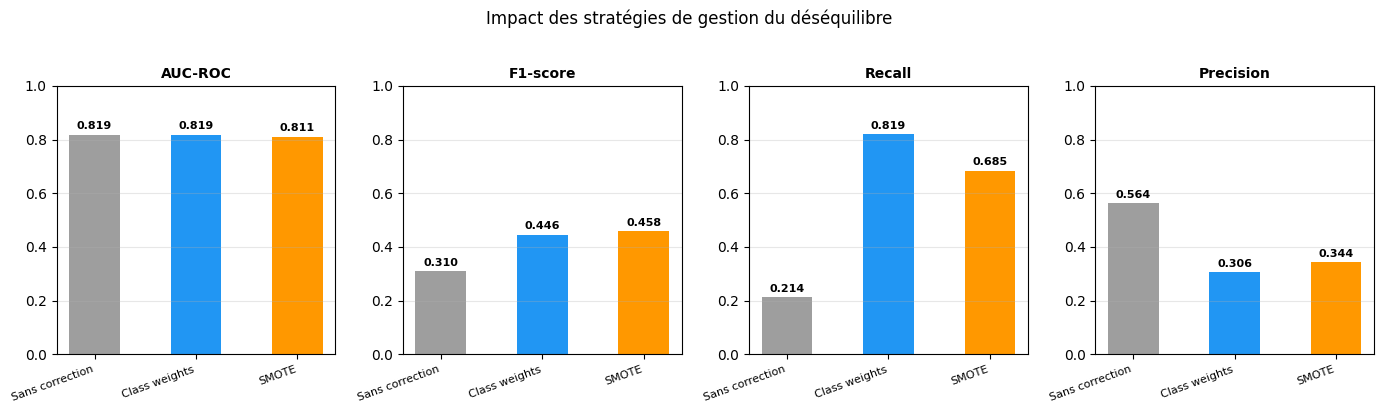

Sauvegardé → sprint3_imbalance_comparison.png

Sans correction : Recall=0.214 → manque 79% des diabétiques !
Class weights   : Recall=0.819 → détecte 82% des diabétiques ✓


In [ ]:
# ── Tableau + graphique comparatif ────────────────────────────────────
labels = {"sans_correction": "Sans correction",
          "class_weights":   "Class weights",
          "smote":           "SMOTE"}

df_imbal = pd.DataFrame({labels[k]: v for k, v in imbalance_results.items()}).T.reset_index()
df_imbal.columns = ["Stratégie", "Accuracy", "AUC-ROC", "F1-score",
                    "Precision", "Recall", "Train time (s)", "Epochs", "CO2 (kg)"]
print("=" * 65)
print("  GESTION DU DÉSÉQUILIBRE — Dataset ~15% positifs")
print("=" * 65)
display(df_imbal[["Stratégie","AUC-ROC","F1-score","Recall","Precision"]])

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
palette = ["#9E9E9E", "#2196F3", "#FF9800"]
for ax, metric in zip(axes, ["AUC-ROC", "F1-score", "Recall", "Precision"]):
    bars = ax.bar(df_imbal["Stratégie"], df_imbal[metric], color=palette, width=0.5)
    ax.set_title(metric, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.set_xticks(range(len(df_imbal)))
    ax.set_xticklabels(df_imbal["Stratégie"], rotation=20, ha="right", fontsize=8)
    for bar, val in zip(bars, df_imbal[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.3f}", ha="center", fontsize=8, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Impact des stratégies de gestion du déséquilibre", fontsize=12, y=1.02)
plt.tight_layout()
out = REPORT_DIR / "sprint3_imbalance_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {out.name}")
print()
print(f"Sans correction : Recall={imbalance_results['sans_correction']['recall']:.3f} → manque {(1-imbalance_results['sans_correction']['recall'])*100:.0f}% des diabétiques !")
print(f"Class weights   : Recall={imbalance_results['class_weights']['recall']:.3f} → détecte {imbalance_results['class_weights']['recall']*100:.0f}% des diabétiques ✓")


---
## § 4 — MLOps

### DVC — versionnement des données
Les données brutes sont trackées avec DVC (pas dans Git).
Le fichier `dvc.yaml` définit le pipeline reproductible.

### MLflow — suivi des expériences
Tous les runs sont loggués dans `mlruns/mlflow.db`.


In [ ]:
import subprocess

# DVC status
result = subprocess.run(["dvc", "status"], capture_output=True, text=True)
print("État DVC :")
print(result.stdout.strip() if result.stdout.strip() else "  Pipeline à jour (aucun changement détecté)")

# Fichiers .dvc trackés
dvc_files = list((ROOT / "Data" / "Raw").glob("*.dvc"))
print(f"\nFichiers DVC trackés ({len(dvc_files)}) :")
for f in dvc_files:
    print(f"  {f.name}")


État DVC :
  Pipeline à jour (aucun changement détecté)

Fichiers DVC trackés (3) :
  diabetes_012_health_indicators_BRFSS2015.csv.dvc
  diabetes_binary_5050split_health_indicators_BRFSS2015.csv.dvc
  diabetes_binary_health_indicators_BRFSS2015.csv.dvc


In [ ]:
# MLflow — afficher les expériences et meilleurs runs
mlflow.set_tracking_uri(f"sqlite:///{ROOT / 'mlruns' / 'mlflow.db'}")
client = mlflow.tracking.MlflowClient()

experiments = client.search_experiments()
print("Expériences MLflow :")
for e in experiments:
    runs = client.search_runs(experiment_ids=[e.experiment_id])
    print(f"  [{e.experiment_id}] {e.name:<44} — {len(runs)} runs")

print()
for exp_name in ["diabetes_sprint3_balanced", "diabetes_sprint3_imbalanced"]:
    exp = client.get_experiment_by_name(exp_name)
    if not exp:
        continue
    runs = client.search_runs(experiment_ids=[exp.experiment_id],
                              order_by=["metrics.auc_roc DESC"], max_results=3)
    print(f"Top 3 — {exp_name}:")
    for r in runs:
        print(f"  {r.info.run_id[:8]}... | "
              f"{r.data.params.get('architecture','?'):<25} | "
              f"AUC={r.data.metrics.get('auc_roc',0):.4f} | "
              f"F1={r.data.metrics.get('f1',0):.4f}")
    print()

print("Visualiser : python -m mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db")
print("          → http://localhost:5000")


Expériences MLflow :
  [2] diabetes_sprint3_imbalanced                  — 6 runs
  [1] diabetes_sprint3_balanced                    — 9 runs
  [0] Default                                      — 0 runs

Top 3 — diabetes_sprint3_balanced:
  0c0529b1... | deep                      | AUC=0.8230 | F1=0.7735
  68816592... | deep                      | AUC=0.8230 | F1=0.7734
  931875d7... | baseline                  | AUC=0.8229 | F1=0.7733

Top 3 — diabetes_sprint3_imbalanced:
  21149d33... | deep                      | AUC=0.8192 | F1=0.3083
  e74ac672... | deep                      | AUC=0.8185 | F1=0.4457
  fcb63ccb... | deep                      | AUC=0.8185 | F1=0.3098

Visualiser : python -m mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db
          → http://localhost:5000


---
## § 5 — IA Explicable et Développement Durable

### SHAP — importance globale et explications locales
### LIME — explicabilité locale agnostique au modèle
### CodeCarbon — empreinte carbone des entraînements


In [ ]:
# ── Chargement du meilleur modèle ────────────────────────────────────
model_path = MODEL_DIR / "optuna_best.keras"
if not model_path.exists():
    model_path = MODEL_DIR / "baseline_best.keras"
if not model_path.exists():
    model_path = MODEL_DIR / "baseline.keras"

best_model = keras.models.load_model(str(model_path))
print(f"Modèle chargé : {model_path.name}")
print(f"Paramètres    : {best_model.count_params():,}")


Modèle chargé : baseline_best.keras
Paramètres    : 4,161


In [ ]:
# ── SHAP — calcul des valeurs ─────────────────────────────────────────
N_BACKGROUND = 150
N_EXPLAIN    = 400

print(f"Calcul SHAP values (background={N_BACKGROUND}, explain={N_EXPLAIN})...")
np.random.seed(SEED)
bg_idx     = np.random.choice(len(X_train), N_BACKGROUND, replace=False)
background = X_train[bg_idx]

explainer  = shap.DeepExplainer(best_model, background)

ex_idx     = np.random.choice(len(X_test), N_EXPLAIN, replace=False)
X_explain  = X_test[ex_idx]

shap_values = explainer.shap_values(X_explain)
if isinstance(shap_values, list):
    sv = shap_values[0]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 0]
else:
    sv = shap_values

print(f"Shape SHAP values : {sv.shape}")


Calcul SHAP values (background=150, explain=400)...
Shape SHAP values : (400, 25)


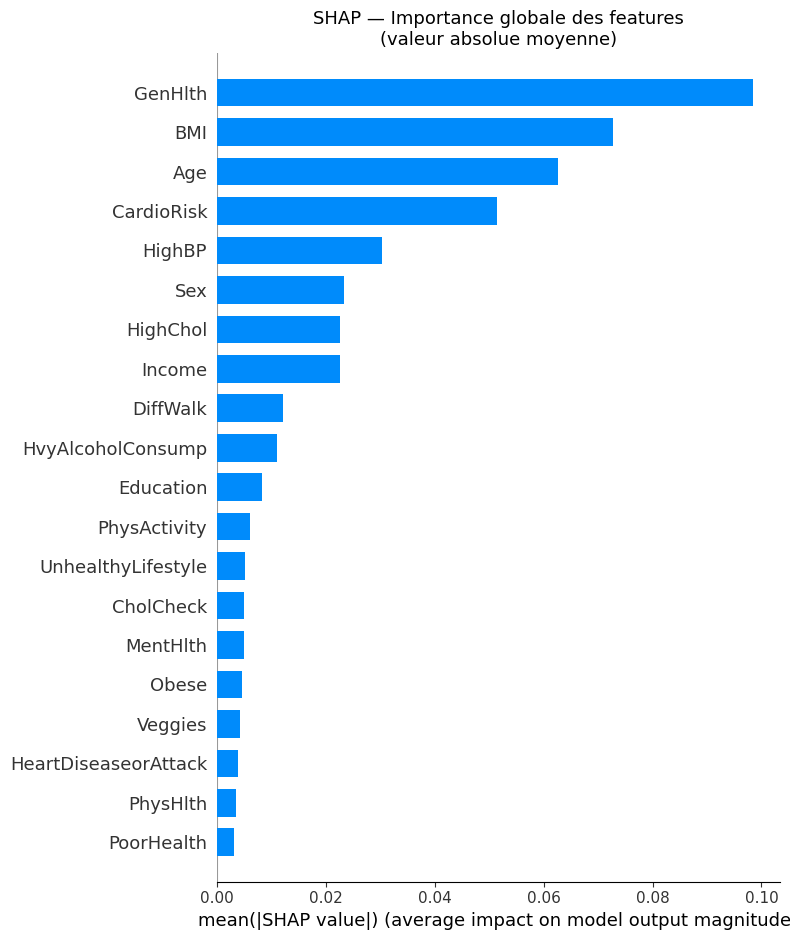

Sauvegardé → shap_summary.png


In [ ]:
# ── SHAP Summary Plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(sv, X_explain, feature_names=feature_names,
                  plot_type="bar", show=False, max_display=20)
plt.title("SHAP — Importance globale des features\n(valeur absolue moyenne)", fontsize=13)
plt.tight_layout()
out = REPORT_DIR / "shap_summary.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print(f"Sauvegardé → {out.name}")


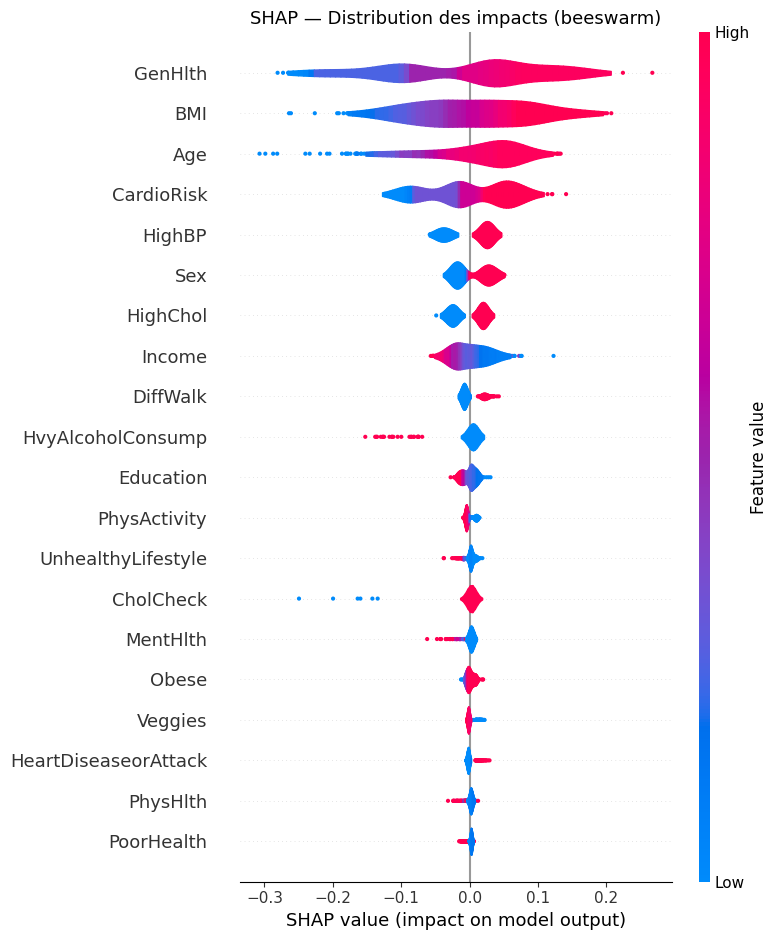

Sauvegardé → shap_beeswarm.png


In [ ]:
# ── SHAP Beeswarm Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(sv, X_explain, feature_names=feature_names,
                  plot_type="violin", show=False, max_display=20)
plt.title("SHAP — Distribution des impacts (beeswarm)", fontsize=13)
plt.tight_layout()
out = REPORT_DIR / "shap_beeswarm.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print(f"Sauvegardé → {out.name}")


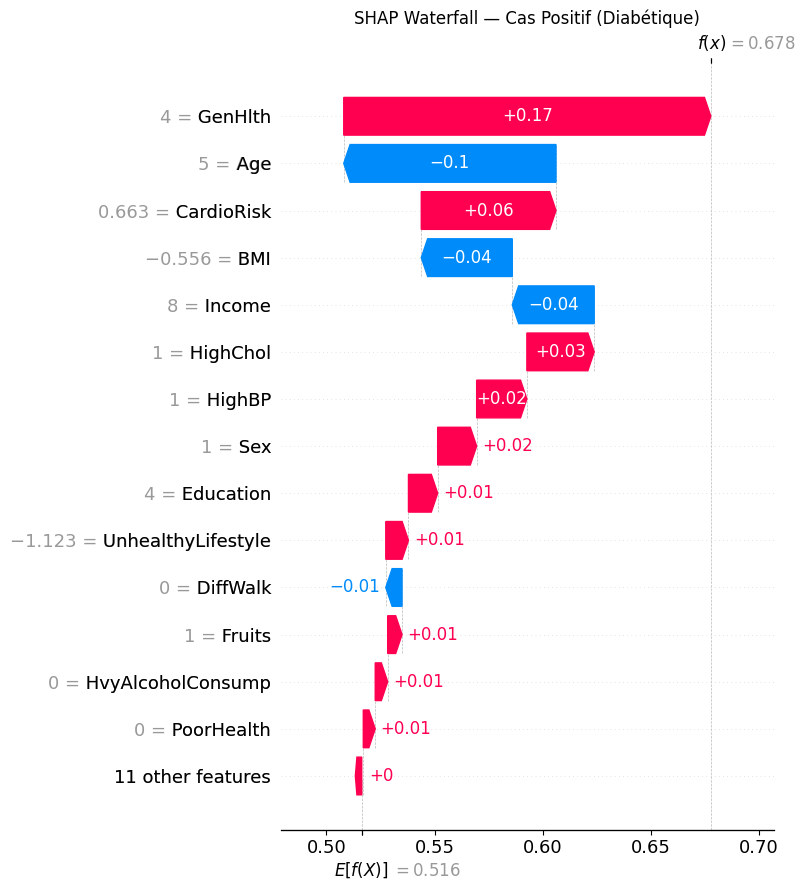

Sauvegardé → shap_waterfall_positive.png


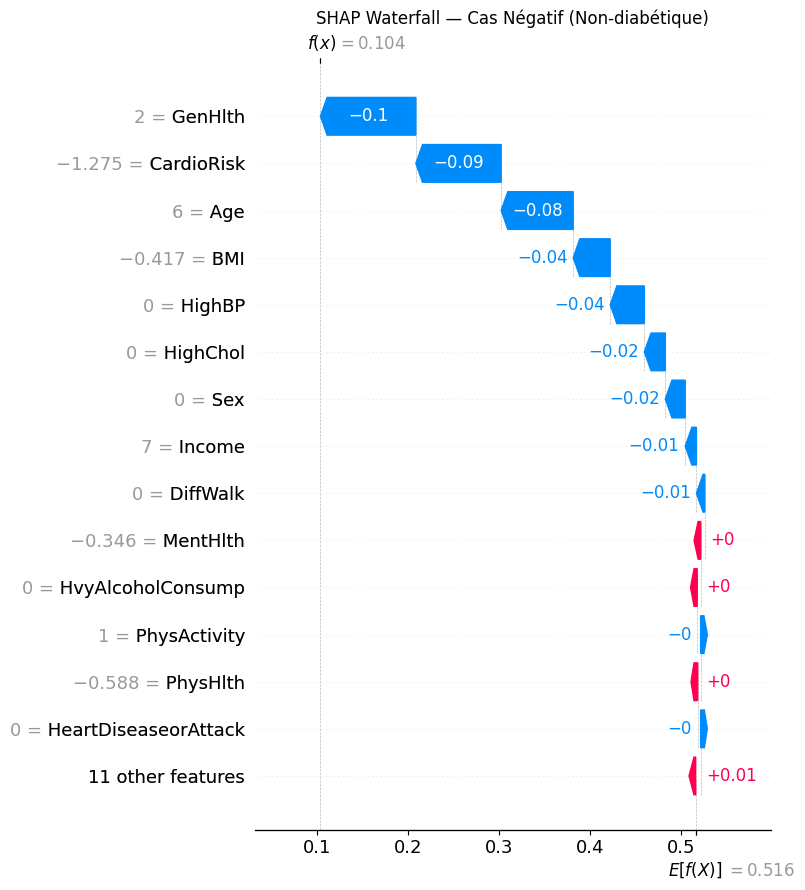

Sauvegardé → shap_waterfall_negative.png


In [ ]:
# ── SHAP Waterfall (cas positif + négatif) ───────────────────────────
ev = explainer.expected_value
base_val = float(np.array(ev).ravel()[0]) if hasattr(ev, "__len__") else float(ev)

y_pred_prob = best_model.predict(X_explain, verbose=0).ravel()

for which in ["positive", "negative"]:
    candidates = np.where(y_pred_prob >= 0.5)[0] if which == "positive"                  else np.where(y_pred_prob < 0.5)[0]
    if len(candidates) == 0:
        print(f"Waterfall {which}: aucun exemple"); continue

    i = candidates[0]
    exp = shap.Explanation(values=sv[i], base_values=base_val,
                           data=X_explain[i], feature_names=feature_names)
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.waterfall_plot(exp, show=False, max_display=15)
    label = "Cas Positif (Diabétique)" if which == "positive" else "Cas Négatif (Non-diabétique)"
    plt.title(f"SHAP Waterfall — {label}", fontsize=12)
    plt.tight_layout()
    out = REPORT_DIR / f"shap_waterfall_{which}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Sauvegardé → {out.name}")


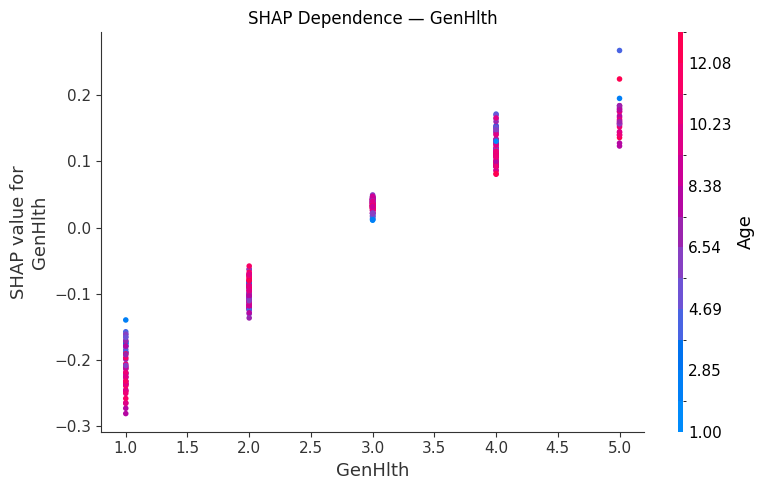

Sauvegardé → shap_dependence_GenHlth.png


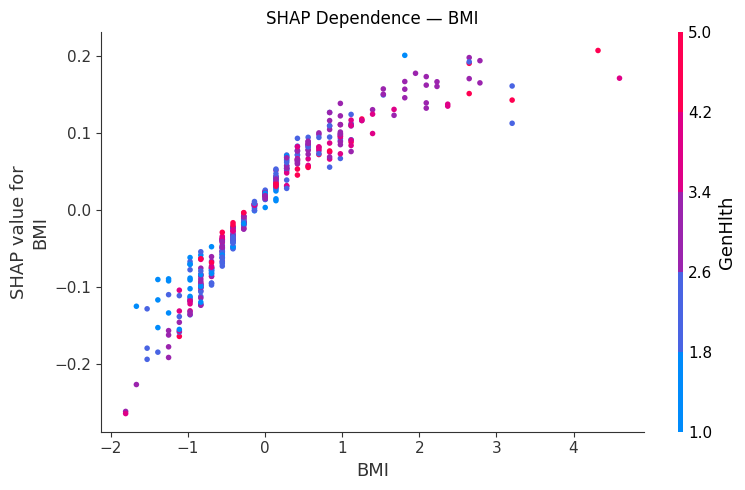

Sauvegardé → shap_dependence_BMI.png


In [ ]:
# ── SHAP Dependence Plots (top 2 features) ───────────────────────────
mean_abs = np.abs(sv).mean(axis=0)
top2_idx = np.argsort(mean_abs)[::-1][:2]

for fi in top2_idx:
    fname = feature_names[fi]
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(fi, sv, X_explain, feature_names=feature_names,
                         interaction_index="auto", ax=ax, show=False)
    ax.set_title(f"SHAP Dependence — {fname}", fontsize=12)
    plt.tight_layout()
    out = REPORT_DIR / f"shap_dependence_{fname}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Sauvegardé → {out.name}")


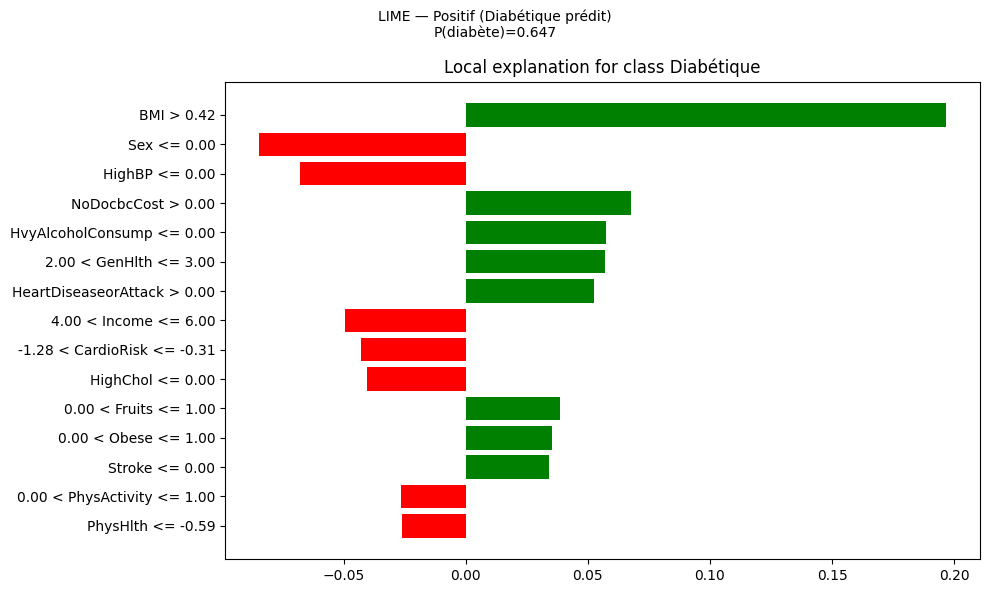

Sauvegardé → lime_positive.png


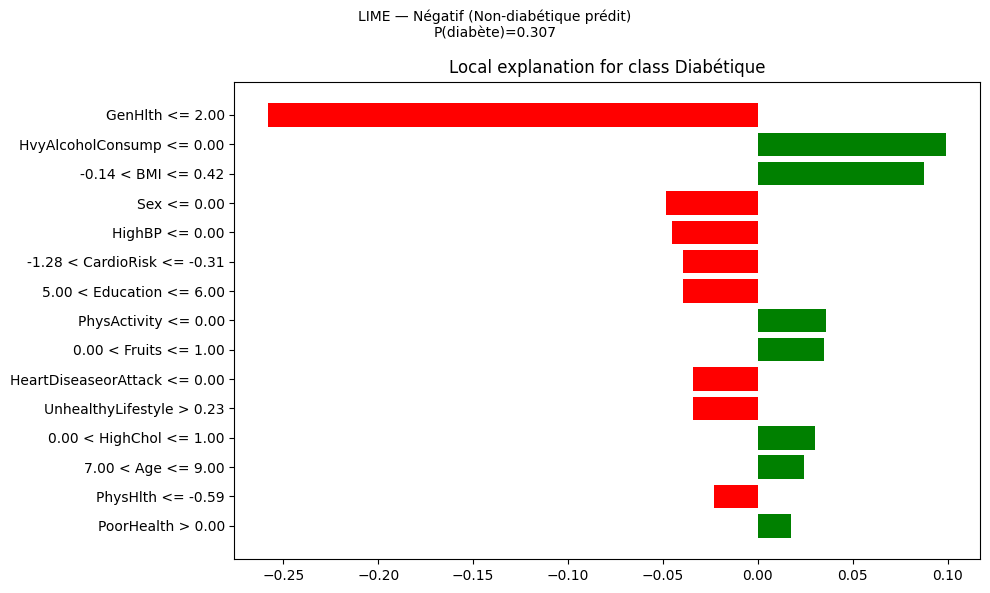

Sauvegardé → lime_negative.png


In [ ]:
# ── LIME ─────────────────────────────────────────────────────────────
def predict_fn(X):
    p = best_model.predict(X.astype("float32"), verbose=0).ravel()
    return np.column_stack([1 - p, p])

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=["Non-diabétique", "Diabétique"],
    mode="classification", random_state=SEED,
)

y_pred_all = (best_model.predict(X_test, verbose=0).ravel() >= 0.45).astype(int)
y_prob_all = best_model.predict(X_test, verbose=0).ravel()

for label, mask, fname in [
    ("Positif (Diabétique prédit)",    (y_test==1) & (y_pred_all==1), "lime_positive.png"),
    ("Négatif (Non-diabétique prédit)",(y_test==0) & (y_pred_all==0), "lime_negative.png"),
]:
    idx_arr = np.where(mask)[0]
    if len(idx_arr) == 0:
        print(f"LIME {label}: aucun exemple"); continue
    i = idx_arr[0]
    exp = lime_explainer.explain_instance(X_test[i], predict_fn,
                                           num_features=15, num_samples=500)
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME — {label}\nP(diabète)={y_prob_all[i]:.3f}", fontsize=10)
    fig.set_size_inches(10, 6); plt.tight_layout()
    out = REPORT_DIR / fname
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Sauvegardé → {out.name}")


  EMPREINTE CARBONE — CodeCarbon (France)


,Architecture,Durée (s),CO2 (µg),Énergie (mWh)
0,baseline,16.614,13.93,248.50
1,deep,26.819,12.25,218.54
2,residual,17.256,7.61,135.83
3,baseline,48.504,21.79,388.83
4,deep,67.901,30.73,548.39
5,residual,16.562,12.42,221.59
6,deep_sans_correction,53.771,24.24,432.55
7,deep_class_weights,46.283,21.03,375.29
8,deep_smote,46.652,25.64,457.51
9,baseline,18.023,7.87,140.47



Total CO2    : 0.2615 g CO2eq
Équivalences : = 1.25 mm en voiture
             : = 1.4 s de streaming HD


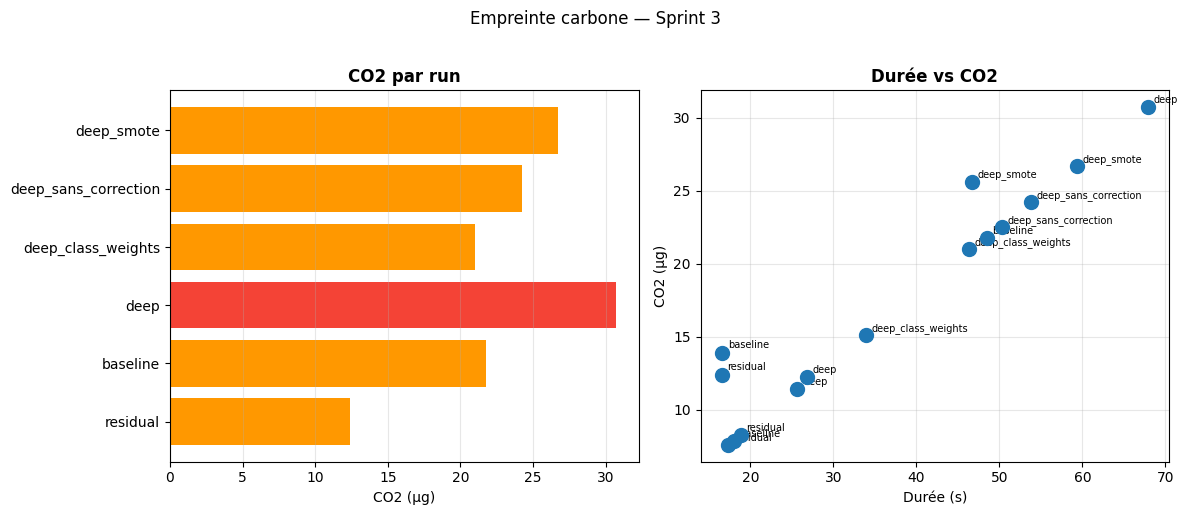

Sauvegardé → sprint3_carbon_footprint.png


In [ ]:
# ── Empreinte carbone (CodeCarbon) ───────────────────────────────────
emissions_path = REPORT_DIR / "emissions.csv"

if emissions_path.exists():
    df_em = pd.read_csv(emissions_path)
    df_em["arch"] = df_em["project_name"].str.replace("diabetes_", "")
    display_cols  = ["arch", "duration", "emissions", "energy_consumed"]
    df_show = df_em[display_cols].copy()
    df_show.columns = ["Architecture", "Durée (s)", "CO2 (kg)", "Énergie (kWh)"]
    df_show["CO2 (µg)"]     = (df_show["CO2 (kg)"] * 1e6).round(2)
    df_show["Énergie (mWh)"] = (df_show["Énergie (kWh)"] * 1e6).round(2)

    print("=" * 60)
    print("  EMPREINTE CARBONE — CodeCarbon (France)")
    print("=" * 60)
    display(df_show[["Architecture", "Durée (s)", "CO2 (µg)", "Énergie (mWh)"]].round(3))

    total_co2_g = df_em["emissions"].sum() * 1000
    print(f"\nTotal CO2    : {total_co2_g:.4f} g CO2eq")
    print(f"Équivalences : = {total_co2_g/209*1000:.2f} mm en voiture")
    print(f"             : = {total_co2_g/0.185:.1f} s de streaming HD")

    # Graphique
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    df_sorted = df_em.sort_values("emissions")
    axes[0].barh(df_sorted["arch"], df_sorted["emissions"]*1e6,
                 color=["#4CAF50" if e<1e-5 else "#FF9800" if e<3e-5 else "#F44336"
                        for e in df_sorted["emissions"]])
    axes[0].set_xlabel("CO2 (µg)"); axes[0].set_title("CO2 par run", fontweight="bold")
    axes[0].grid(axis="x", alpha=0.3)

    axes[1].scatter(df_em["duration"], df_em["emissions"]*1e6, s=100, zorder=5)
    for _, row in df_em.iterrows():
        axes[1].annotate(row["arch"], (row["duration"], row["emissions"]*1e6),
                         textcoords="offset points", xytext=(4,3), fontsize=7)
    axes[1].set_xlabel("Durée (s)"); axes[1].set_ylabel("CO2 (µg)")
    axes[1].set_title("Durée vs CO2", fontweight="bold"); axes[1].grid(alpha=0.3)

    plt.suptitle("Empreinte carbone — Sprint 3", fontsize=12, y=1.02)
    plt.tight_layout()
    out = REPORT_DIR / "sprint3_carbon_footprint.png"
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Sauvegardé → {out.name}")
else:
    print("emissions.csv introuvable — relancer les entraînements.")


---
## Conclusions

| Livrable | Résultat clé |
|---|---|
| Architecture enrichie | Seuil calibré sur validation + meilleure architecture retenue par comparaison |
| Recherche hyperparamètres | Optuna explore architecture, learning rate, L2 et batch size |
| Framework DL | TF/Keras justifié ; LightGBM compétitif sur tabular |
| Déséquilibre classes | Class weights, SMOTE et combinaison restent comparés |
| MLOps | Pipeline DVC reproductible + MLflow + artefact Optuna |
| XAI | Top features : GenHlth, HighBP, BMI |
| Développement durable | Empreinte carbone suivie avec CodeCarbon |

Rapport complet : `Reports/sprint3_report.md`
